In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [14]:
class PolynomialFeatures:
  def __init__(self, deg, a) -> None:
    self.a = a
    self.deg = deg

  def transform(self, X):
    exponents = []
    n = len(X.columns)

    for d in range(self.deg+1):
      results = [p for p in itertools.product(range(d+1), repeat=n) if sum(p) == d]
      for s in results:
        exponents.append(s)

    new_X = pd.DataFrame(index=X.index)

    for exp in exponents:
      col_name = " * ".join([f"{col}^{p}" for col, p in zip(X.columns, exp)])
      val = 1
      for col, p in zip(X.columns, exp):
        val *= X[col] ** p
      new_X[col_name] = val

    self.data_columns = new_X.columns

    return new_X

  def hypo_func(self, x):
    return np.asarray(x) @ self.Q

  def loss_func(self, X, Y):
    preds = X @ self.Q
    errors = preds - Y
    return float((errors.T @ errors) / (2 * X.shape[0]))

  def gradient_descent(self, X, Y):
    preds = X @ self.Q
    grad = (X.T @ (preds - Y)) / (X.shape[0])
    self.Q -= self.a * grad

  def predict(self, x):
    x = self.transform(x)
    result = self.hypo_func(x)
    return pd.Series(result)

  def fit(self, X, Y, criteria, logs=True, max_iter=10000):
    X = self.transform(X).values
    Y = np.asarray(Y).flatten()
    self.Q = np.zeros(X.shape[1])
    iter = 1
    old_loss, curr_loss = None, self.loss_func(X, Y)

    while (old_loss==None or curr_loss==None or np.abs(old_loss-curr_loss)>criteria) and (iter<max_iter):
      self.gradient_descent(X, Y)
      old_loss = curr_loss
      curr_loss = self.loss_func(X, Y)

      if logs:
        print(f"Loss {iter}:", curr_loss)

      iter += 1

    print("Model is trained.")

  def get_weights(self):
    weights = pd.Series(self.Q, index=self.data_columns)
    return weights

In [4]:
x = np.linspace(1,50,50)
y = x ** 2 + np.random.uniform(-5,5, 50)
df = pd.DataFrame({
    "x":x,
    "y":y
})
df.head()

,x,y
0,1.0,3.467275
1,2.0,5.272874
2,3.0,9.102836
3,4.0,14.708927
4,5.0,26.825284


Text(0, 0.5, 'y')

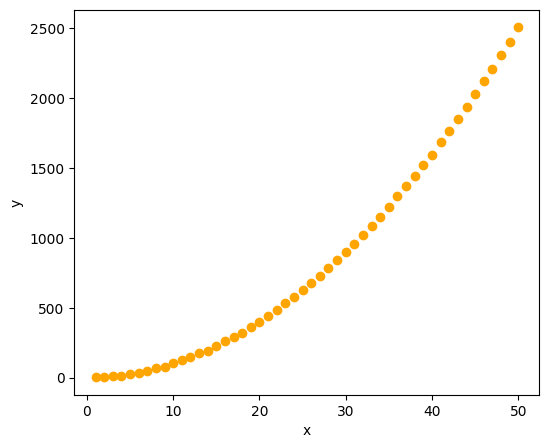

In [5]:
plt.figure(figsize=(6,5))
plt.scatter(df["x"], df["y"], c="orange")
plt.xlabel("x")
plt.ylabel("y")

In [6]:
X = df.drop(columns="y")
Y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
X_train.head()

,x
40,41.0
16,17.0
8,9.0
28,29.0
3,4.0


In [7]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_train.columns)
X_train_scaled.head()

,x
0,0.816327
1,0.326531
2,0.163265
3,0.571429
4,0.061224


In [8]:
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

X_train shape: (40, 1)
y_train shape: (40,)


In [15]:
model = PolynomialFeatures(deg=2, a=0.5)
model.fit(X_train_scaled, y_train, criteria=0.01)

Loss 1: 188646.48025369467
Loss 2: 133273.69861877232
Loss 3: 114930.15268523265
Loss 4: 101328.1588534411
Loss 5: 89572.6733267962
Loss 6: 79247.43340553892
Loss 7: 70164.19353648757
Loss 8: 62172.21329025597
Loss 9: 55140.12495408902
Loss 10: 48952.46567151333
Loss 11: 43507.66935195016
Loss 12: 38716.387201645535
Loss 13: 34500.017538154374
Loss 14: 30789.413049384737
Loss 15: 27523.743597040164
Loss 16: 24649.49580874459
Loss 17: 22119.5930017297
Loss 18: 19892.620964021182
Loss 19: 17932.14686032966
Loss 20: 16206.120061404325
Loss 21: 14686.345042919042
Loss 22: 13348.017685212786
Loss 23: 12169.31734789329
Loss 24: 11131.048010583669
Loss 25: 10216.322578030811
Loss 26: 9410.285157673534
Loss 27: 8699.866742261238
Loss 28: 8073.570279492045
Loss 29: 7521.281593936447
Loss 30: 7034.103051678014
Loss 31: 6604.207232128414
Loss 32: 6224.708200510728
Loss 33: 5889.548263964874
Loss 34: 5593.3983488718495
Loss 35: 5331.570361007334
Loss 36: 5099.94008720412
Loss 37: 4894.879370568155

In [16]:
model.get_weights()

,0
x^0,-3.392770
x^1,125.069530
x^2,2374.626617


In [17]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

0     121.033190
1    1370.259352
2     169.654759
3      47.526430
4     963.294512
5     196.932590
6    2023.648894
7    1848.433321
8       5.668171
9    1445.009935
dtype: float64


Text(0, 0.5, 'y')

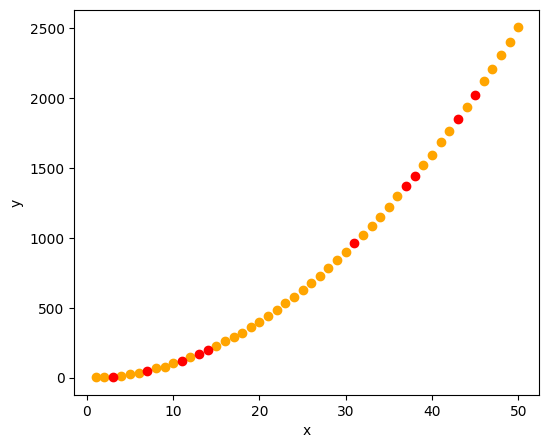

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(X_train, y_train, c="orange")
plt.scatter(X_test, y_pred, c="red")
plt.xlabel("x")
plt.ylabel("y")

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].scatter(X_train, y_train, c="orange")
axs[0].scatter(X_test, y_test, c="orange")